# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [61]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df_genes = pd.read_csv("./data/df_genes_aula6exer7.csv", index_col="Unnamed: 0")
df_genes.head()

,num_letras,primeiras_duas_letras,num_a,contains_hu
isg15,5,is,0,False
hur,3,hu,0,True
ifna,4,if,1,False
tnfa,4,tn,1,False
atpsf1a,7,at,2,False


In [63]:
df_genes['id_entrez'] = [
    "NM_005101.4",
    "NM_001419.3",
    "NM_024013.3",
    "NM_001270508.2",
    "NM_004046.6",
]

df_genes['id_protein'] = [
    'NP_005092.1',
    "NP_001410.2",
    "NP_000596.2",
    "NP_001257437.1",
    "NP_004037.1",
]
df_genes

,num_letras,primeiras_duas_letras,num_a,contains_hu,id_entrez,id_protein
isg15,5,is,0,False,NM_005101.4,NP_005092.1
hur,3,hu,0,True,NM_001419.3,NP_001410.2
ifna,4,if,1,False,NM_024013.3,NP_000596.2
tnfa,4,tn,1,False,NM_001270508.2,NP_001257437.1
atpsf1a,7,at,2,False,NM_004046.6,NP_004037.1


In [64]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "seu@email.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./exercicios/data/{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [65]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    # salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

isg15 NP_005092.1
hur NP_001410.2
ifna NP_000596.2
tnfa NP_001257437.1
atpsf1a NP_004037.1


In [66]:
descr_gene = {}
for gene in df_genes.index:
    caminho = f"./exercicios/data/{gene}.fasta"
    with open(caminho, 'r') as file:
        data = file.read()
        data = data.split('\n')
        cod = data[0].split(" ")[0]
        seq = ''.join(data[1:-2])
        descr_gene[gene] = {"gene": gene, "cod": cod, "seq": seq}
descr_gene_df = pd.DataFrame.from_dict(descr_gene, orient='index')
descr_gene_df.head()

,gene,cod,seq
isg15,isg15,>NP_005092.1,MGWDLTVKMLAGNEFQVSLSSSMSVSELKAQITQKIGVHAFQQRLA...
hur,hur,>NP_001410.2,MSNGYEDHMAEDCRGDIGRTNLIVNYLPQNMTQDELRSLFSSIGEV...
ifna,ifna,>NP_000596.2,MALTFALLVALLVLSCKSSCSVGCDLPQTHSLGSRRTLMLLAQMRR...
tnfa,tnfa,>NP_001257437.1,MAEQVLPQALYLSNMRKAVKIRERTPEDIFKPTNGIIHHFKTMHRY...
atpsf1a,atpsf1a,>NP_004037.1,MLSVRVAAAVVRALPRRAGLVSRNALGSSFIAARNFHASNTHLQKT...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [67]:
aa_coding_data = pd.read_csv('./exercicios_resolvidos/data/aa_codign.txt', sep='\t')
aa_coding_data

,Amino Acid,Three letter code,One letter code,MW
0,Alanine,Ala,A,89.09
1,Arginine,Arg,R,174.20
2,Asparagine,Asn,N,132.12
3,Aspartic Acid,Asp,D,133.10
4,Cysteine,Cys,C,121.16
5,Glutamic Acid,Glu,E,147.13
6,Glutamine,Gln,Q,146.15
7,Glycine,Gly,G,75.07
8,Histidine,His,H,155.16
9,Isoleucine,Ile,I,131.18


In [68]:
obj_lista = []
for carac in aa_coding_data['One letter code'].values:
    temp_list = list(map(lambda x: x.count(carac), descr_gene_df['seq']))
    obj_lista.append(temp_list)

aa_data = pd.DataFrame(
    data=obj_lista,
    index=aa_coding_data['Amino Acid'].values,
    columns=descr_gene_df['gene'].values
)
aa_data

,isg15,hur,ifna,tnfa,atpsf1a
Alanine,7,23,11,50,58
Arginine,8,20,10,56,38
Asparagine,4,23,4,40,16
Aspartic Acid,7,16,8,30,29
Cysteine,1,3,6,40,2
Glutamic Acid,9,15,14,57,31
Glutamine,12,12,12,39,25
Glycine,18,29,6,45,51
Histidine,3,8,3,30,7
Isoleucine,3,19,8,27,39


In [70]:
aa_data.to_csv('./exercicios_resolvidos/data/aa_count.csv')

## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [9]:
data = aa_data.loc['Valine'].sort_values(ascending=False)
data

atpsf1a    46
tnfa       29
hur        22
isg15      16
ifna       10
Name: Valine, dtype: int64

R.: atpsf1a têm o maior número de Valinas, 46.

## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [11]:
data = aa_data.loc['Serine'].sort_values(ascending=False)
data

tnfa       53
atpsf1a    39
hur        28
ifna       18
isg15      15
Name: Serine, dtype: int64

In [15]:
f"Média de serina em cada gene: {data.mean()}"

'Média de serina em cada gene: 30.6'

In [17]:
f"Mediana de serina em cada gene: {data.median()}"

'Mediana de serina em cada gene: 28.0'

In [20]:
print("Moda de serina em cada gene:")
data.value_counts().sort_values()

Moda de serina em cada gene:


53    1
39    1
28    1
18    1
15    1
Name: Serine, dtype: int64

## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

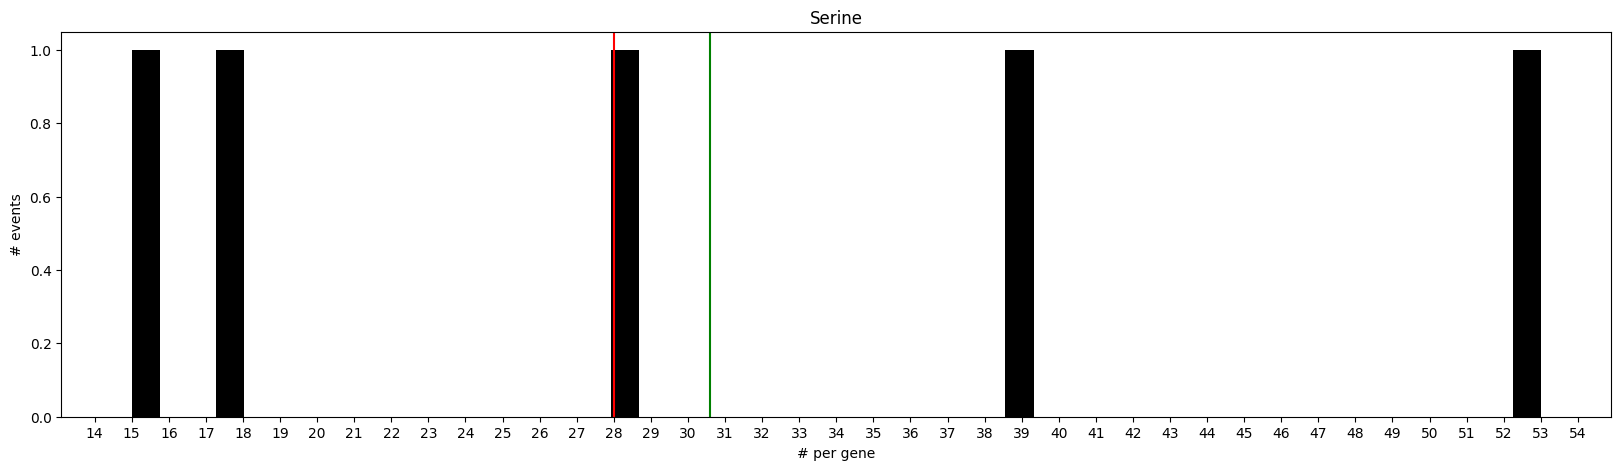

In [21]:
plt.figure(figsize=(20,5))
plt.hist(
    data,
    bins=50,
    color='black'
)
plt.title("Serine")
plt.xlabel('# per gene')
plt.ylabel('# events')
plt.xticks(
    np.arange(
        data.min()-1,
        data.max()+2
    )
)
plt.axvline(data.mean(), 0, 1, color='g')
plt.axvline(data.median(), 0, 1, color='r')
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [ ]:
def plotar_histograma(marc: str) -> None:
    '''
        Plota um histograma para a contagem de um aminoácido específico em cada gene.
            Args:
                marc (str): Nome do aminoácido a ser plotado.
            Returns:
                None
    '''
    data = aa_data.loc[marc].sort_values(ascending=False)
    plt.figure(figsize=(20,5))
    plt.hist(
        data,
        bins=50,
        color='black'
    )
    plt.title(marc)
    plt.xlabel('# per gene')
    plt.ylabel('# events')
    plt.xticks(
        np.arange(
            data.min()-1,
            data.max()+2
        )
    )
    plt.axvline(data.mean(), 0, 1, color='g')
    plt.axvline(data.median(), 0, 1, color='r')
    plt.show()

    return None

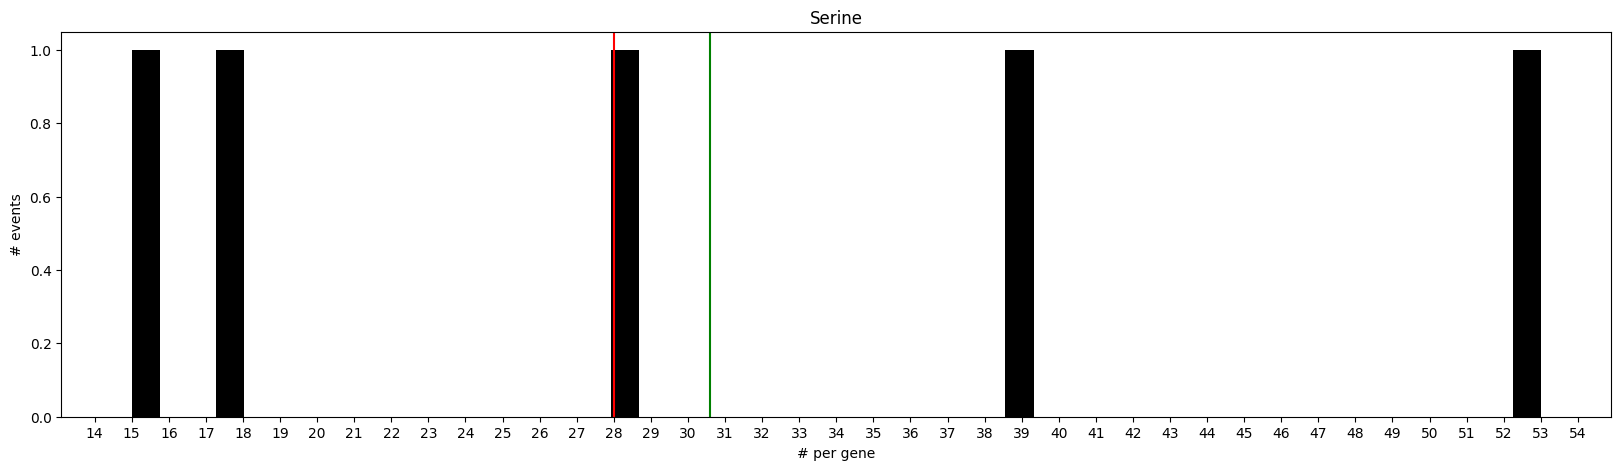

In [23]:
plotar_histograma(marc='Serine')

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

In [40]:
from util import utils as ut

In [41]:
ut.meus_uteis()

-------------
-=< Lista >=-
-------------
0 -> printLinha()
1 -> printLis()
2 -> printDic()
3 -> timeProcess()
4 -> import_started()
5 -> img_save()
6 -> setup_img_save()
7 -> mask_corr_graphic()
8 -> structured_confusion()


In [42]:
ut.printLis(aa_data.index)

-------------
-=< Lista >=-
-------------
0 -> Alanine
1 -> Arginine
2 -> Asparagine
3 -> Aspartic Acid
4 -> Cysteine
5 -> Glutamic Acid
6 -> Glutamine
7 -> Glycine
8 -> Histidine
9 -> Isoleucine
10 -> Leucine
11 -> Lysine
12 -> Methionine
13 -> Phenylalanine
14 -> Proline
15 -> Serine
16 -> Threonine
17 -> Tryptophan
18 -> Tyrosine
19 -> Valine


In [46]:
marcs = [6, 7, 11, 19]
aa_data.iloc[marcs, :]

,isg15,hur,ifna,tnfa,atpsf1a
Glutamine,12,12,12,39,25
Glycine,18,29,6,45,51
Lysine,8,18,11,46,30
Valine,16,22,10,29,46


Plotando histograma para Glutamine...


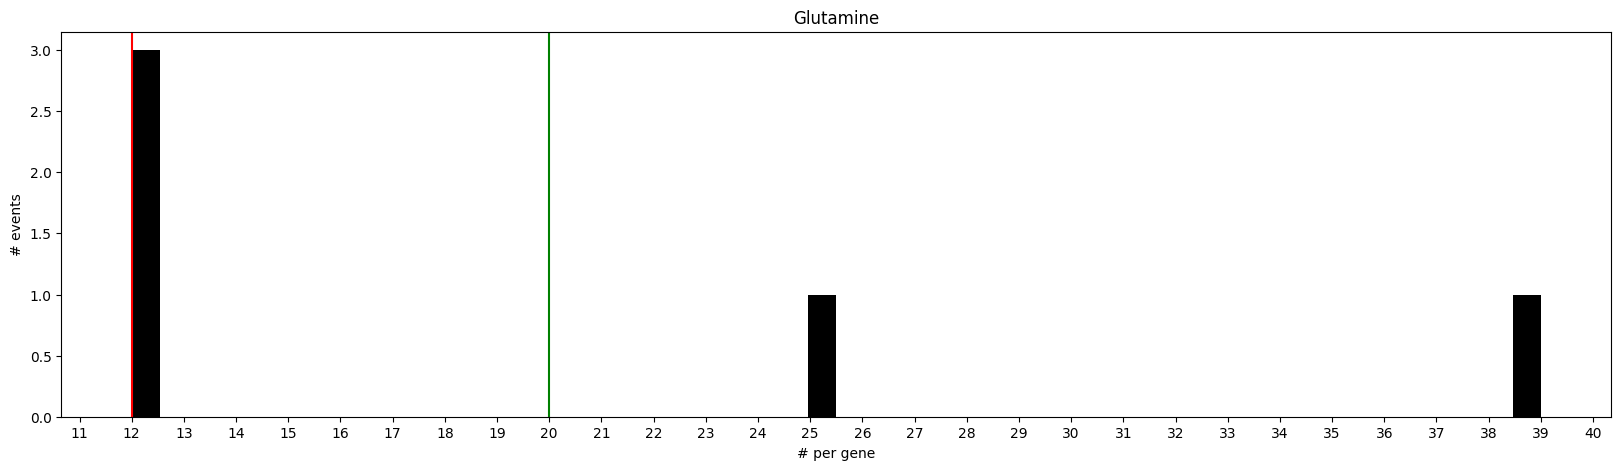

Plotando histograma para Glycine...


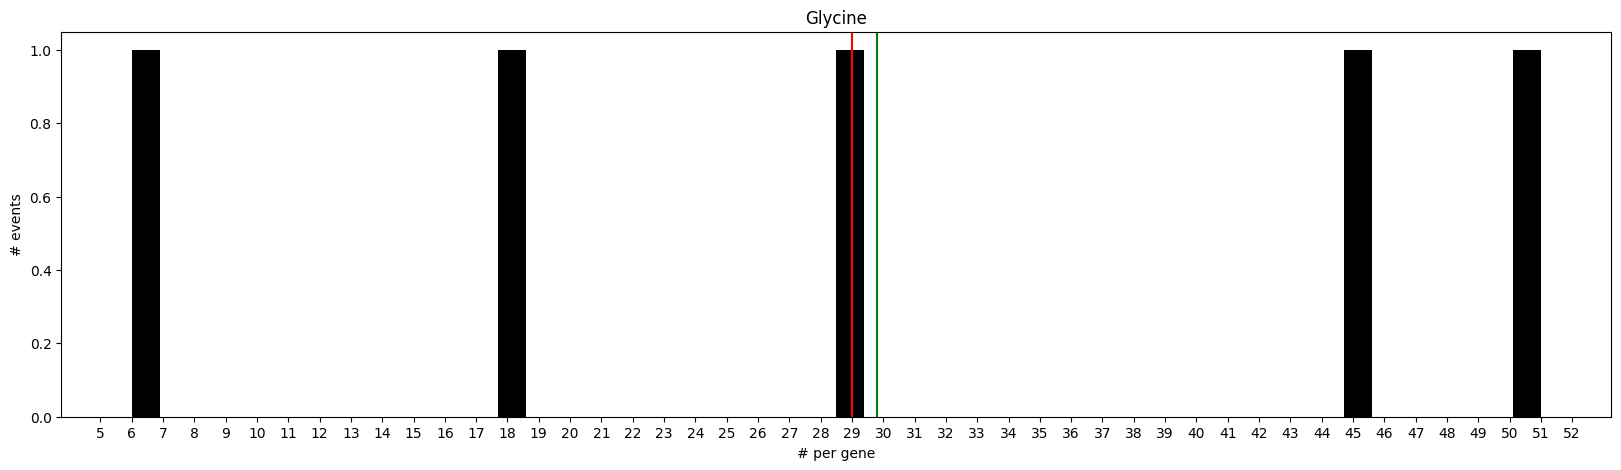

Plotando histograma para Lysine...


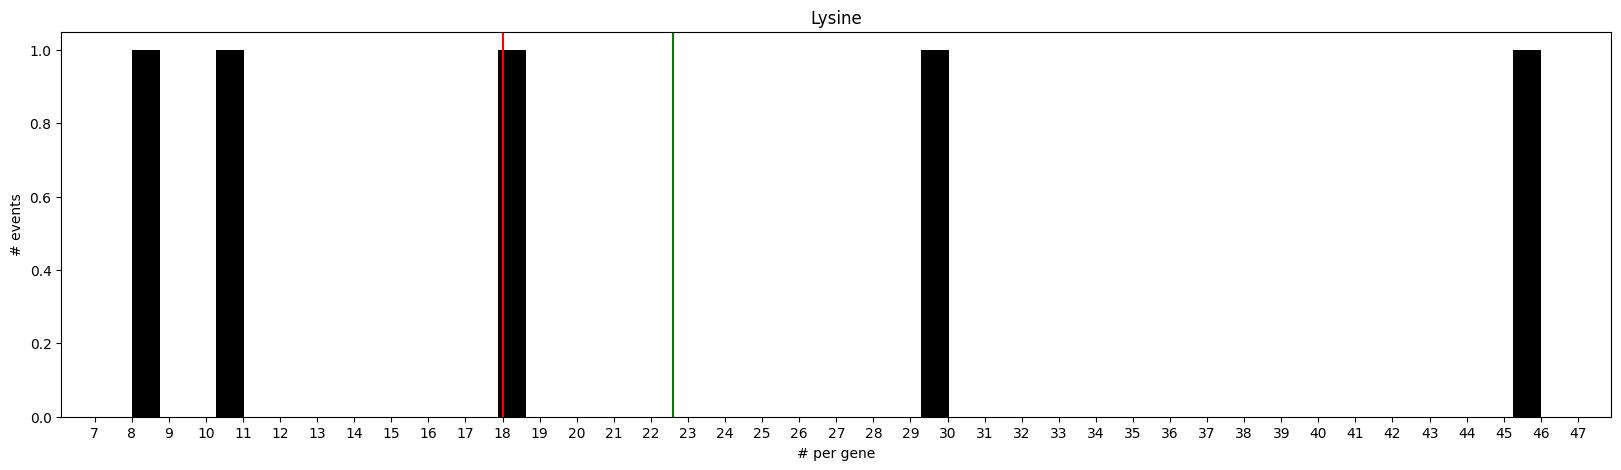

Plotando histograma para Valine...


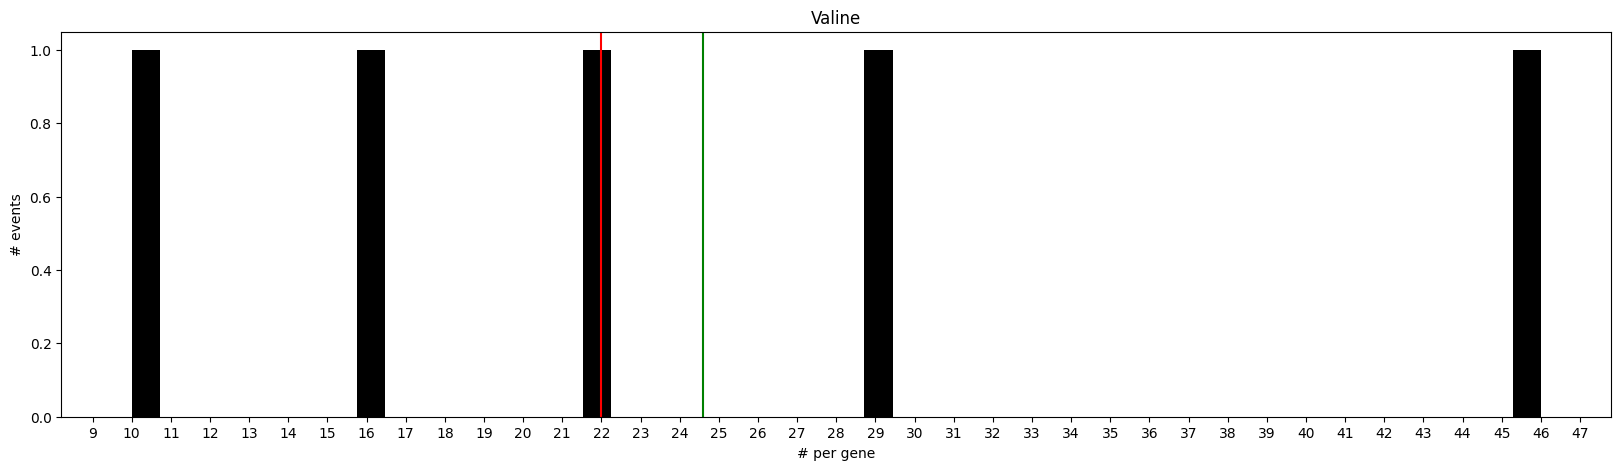

In [47]:
for marc in marcs:
    print(f"Plotando histograma para {aa_data.index[marc]}...")
    plotar_histograma(marc=aa_data.index[marc])

R.: A menor diferença é observada em Glicina

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [50]:
aa_data.iloc[4, :3].mean()

3.3333333333333335

In [51]:
aa_data.iloc[4, :3].median()

3.0

## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [52]:
aa_data.describe()

,isg15,hur,ifna,tnfa,atpsf1a
count,20.000000,20.000000,20.000000,20.00000,20.000000
mean,8.250000,16.300000,9.400000,39.50000,27.650000
std,6.068686,7.427545,5.734476,14.73092,16.906165
min,1.000000,2.000000,2.000000,9.00000,0.000000
25%,3.750000,11.500000,5.750000,29.75000,16.000000
50%,7.500000,17.000000,9.000000,40.00000,28.000000
75%,9.750000,22.000000,11.000000,50.75000,39.000000
max,24.000000,29.000000,27.000000,64.00000,58.000000


In [53]:
aa_data.describe().loc['mean']

isg15       8.25
hur        16.30
ifna        9.40
tnfa       39.50
atpsf1a    27.65
Name: mean, dtype: float64

In [54]:
aa_data.describe().loc['mean'].max()

39.5

In [59]:
aa_data.describe()[aa_data.describe().loc['mean'].max() == aa_data.describe()].fillna("-")

,isg15,hur,ifna,tnfa,atpsf1a
count,-,-,-,-,-
mean,-,-,-,39.5,-
std,-,-,-,-,-
min,-,-,-,-,-
25%,-,-,-,-,-
50%,-,-,-,-,-
75%,-,-,-,-,-
max,-,-,-,-,-


In [ ]:
aa_data.describe()[aa_data.describe().loc['mean'].max() == aa_data.describe()].fillna("-").loc['mean', :]

isg15         -
hur           -
ifna          -
tnfa       39.5
atpsf1a       -
Name: mean, dtype: object

## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [60]:
aa_data.describe()[aa_data.describe().loc['mean'].min() == aa_data.describe()].fillna("-")

,isg15,hur,ifna,tnfa,atpsf1a
count,-,-,-,-,-
mean,8.25,-,-,-,-
std,-,-,-,-,-
min,-,-,-,-,-
25%,-,-,-,-,-
50%,-,-,-,-,-
75%,-,-,-,-,-
max,-,-,-,-,-


In [58]:
aa_data.describe()[aa_data.describe().loc['mean'].min() == aa_data.describe()].fillna("-").loc['mean', :]

isg15      8.25
hur           -
ifna          -
tnfa          -
atpsf1a       -
Name: mean, dtype: object